# NYC Yellow Taxi — Trip Delay Analysis & Prediction

## 01 Project Introduction

This project analyses NYC Yellow Taxi trips to understand and predict trip delay risk.

The main business question is:

**Can we predict whether a NYC taxi trip will run significantly longer than expected, and what factors drive delay risk?**

The project uses January 2023 NYC Yellow Taxi trip records. The analysis includes data cleaning, exploratory analysis, feature engineering, regression modelling, classification modelling, and geospatial analysis.

In [1]:
# ============================================
# 01 SETUP
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

## 02 Dataset Overview

The dataset contains NYC Yellow Taxi trip records for January 2023. Each row represents one completed taxi trip.

The raw dataset is large, so a 100,000-row sample is used to keep the notebook efficient while still preserving enough observations for meaningful analysis.

In [3]:
# ============================================
# 02 LOAD DATA
# ============================================

DATA_PATH = "yellow_tripdata_2023-01.parquet"

df_raw = pd.read_parquet(DATA_PATH)

print("Raw dataset shape:", df_raw.shape)

df_raw.head()

Raw dataset shape: (3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.000,0.970,1.000,N,161,141,2,9.300,1.000,0.500,0.000,0.000,1.000,14.300,2.500,0.000
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.000,1.100,1.000,N,43,237,1,7.900,1.000,0.500,4.000,0.000,1.000,16.900,2.500,0.000
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.000,2.510,1.000,N,48,238,1,14.900,1.000,0.500,15.000,0.000,1.000,34.900,2.500,0.000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.000,1.900,1.000,N,138,7,1,12.100,7.250,0.500,0.000,0.000,1.000,20.850,0.000,1.250
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.000,1.430,1.000,N,107,79,1,11.400,1.000,0.500,3.280,0.000,1.000,19.680,2.500,0.000


In [4]:
# Sample data for faster portfolio analysis

df = df_raw.sample(n=100000, random_state=RANDOM_STATE).copy()

print("Sampled dataset shape:", df.shape)

df.head()

Sampled dataset shape: (100000, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2790731,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.000,1.170,1.000,N,262,74,2,7.200,0.000,0.500,0.000,0.000,1.000,11.200,2.500,0.000
666153,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.000,0.900,1.000,N,229,237,2,6.500,2.500,0.500,0.000,0.000,1.000,10.500,2.500,0.000
1985683,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.000,0.950,1.000,N,45,261,1,7.900,0.000,0.500,2.380,0.000,1.000,14.280,2.500,0.000
2154231,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.000,0.880,1.000,N,237,141,1,16.300,2.500,0.500,1.500,0.000,1.000,24.300,2.500,0.000
2493619,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.000,1.030,1.000,N,229,140,1,6.500,1.000,0.500,2.300,0.000,1.000,13.800,2.500,0.000


In [5]:
# Basic dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 2790731 to 13812
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int64         
 1   tpep_pickup_datetime   100000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  100000 non-null  datetime64[us]
 3   passenger_count        97714 non-null   float64       
 4   trip_distance          100000 non-null  float64       
 5   RatecodeID             97714 non-null   float64       
 6   store_and_fwd_flag     97714 non-null   object        
 7   PULocationID           100000 non-null  int64         
 8   DOLocationID           100000 non-null  int64         
 9   payment_type           100000 non-null  int64         
 10  fare_amount            100000 non-null  float64       
 11  extra                  100000 non-null  float64       
 12  mta_tax                100000 non-null  floa

In [6]:
# Column names

df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

In [7]:
# Basic missing value check

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

airport_fee             2286
congestion_surcharge    2286
passenger_count         2286
RatecodeID              2286
store_and_fwd_flag      2286
dtype: int64

In [8]:
# Duplicate row check

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Initial observations

The dataset contains timestamp fields, trip distance, passenger count, pickup and dropoff location IDs, payment information, and fare-related columns.

Some fields contain missing values, especially passenger count, rate code, store-and-forward flag, congestion surcharge, and airport fee. These missing values need to be reviewed before modelling.

The next step is to create the trip duration variable and identify unrealistic duration and distance values.

In [10]:
df_raw.shape
df.shape
missing_values[missing_values > 0]
duplicate_count

np.int64(0)

## 03 Data Quality Checks

Before modelling, we need to check whether the trip duration and trip distance values are realistic.

Trip duration is calculated as the difference between the dropoff timestamp and pickup timestamp. This will help identify records with zero, extremely short, or extremely long trip times.

In [12]:
# ============================================
# 03 CREATE TRIP DURATION
# ============================================

df["duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "duration_min", "trip_distance"]].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,duration_min,trip_distance
2790731,2023-01-29 17:52:02,2023-01-29 17:56:43,4.683,1.170
666153,2023-01-08 15:57:24,2023-01-08 16:02:47,5.383,0.900
1985683,2023-01-21 19:38:01,2023-01-21 19:45:02,7.017,0.950
2154231,2023-01-23 16:07:31,2023-01-23 16:26:46,19.250,0.880
2493619,2023-01-26 21:21:08,2023-01-26 21:24:48,3.667,1.030


In [13]:
# Summary statistics for duration and distance

df[["duration_min", "trip_distance"]].describe()

,duration_min,trip_distance
count,100000.000,100000.000
mean,15.659,3.465
std,42.026,26.092
min,0.000,0.000
25%,7.117,1.060
50%,11.500,1.790
75%,18.283,3.333
max,1439.117,7729.750


In [14]:
# Check unrealistic values before cleaning

quality_checks = {
    "negative_or_zero_duration": (df["duration_min"] <= 0).sum(),
    "duration_less_than_1_min": (df["duration_min"] < 1).sum(),
    "duration_over_2_hours": (df["duration_min"] > 120).sum(),
    "zero_or_negative_distance": (df["trip_distance"] <= 0).sum(),
    "distance_over_50_miles": (df["trip_distance"] > 50).sum()
}

quality_checks

{'negative_or_zero_duration': np.int64(27),
 'duration_less_than_1_min': np.int64(1127),
 'duration_over_2_hours': np.int64(102),
 'zero_or_negative_distance': np.int64(1519),
 'distance_over_50_miles': np.int64(12)}

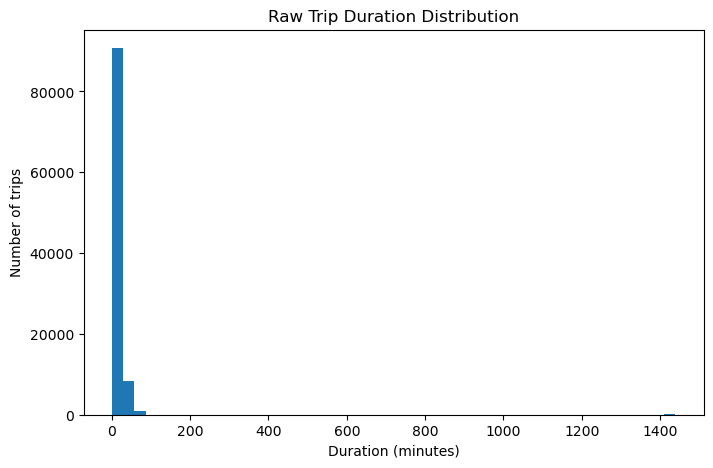

In [15]:
# Visualise raw duration distribution

plt.figure(figsize=(8, 5))
plt.hist(df["duration_min"], bins=50)
plt.title("Raw Trip Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of trips")
plt.show()

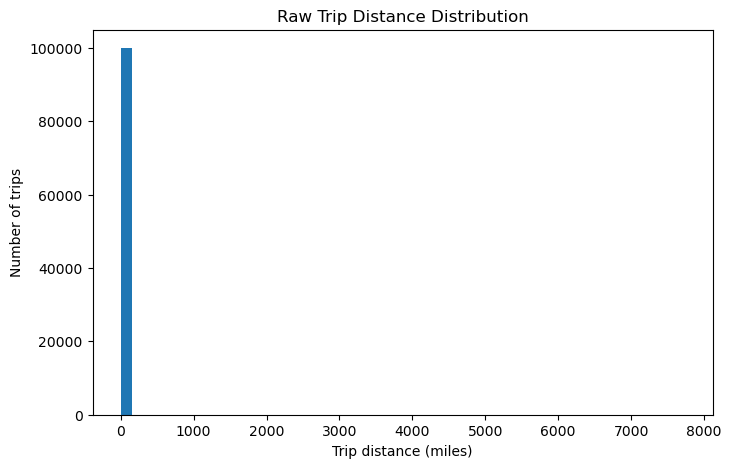

In [16]:
# Visualise raw trip distance distribution

plt.figure(figsize=(8, 5))
plt.hist(df["trip_distance"], bins=50)
plt.title("Raw Trip Distance Distribution")
plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.show()

### Data quality interpretation

The raw duration and distance distributions are highly skewed. Most trips are short, but the dataset contains extreme values such as very long durations and unrealistic distances.

These values could distort both the exploratory analysis and the model training process. The next step is to apply cleaning rules that keep trips within realistic operational ranges.

In [17]:
df[["duration_min", "trip_distance"]].describe()
quality_checks

{'negative_or_zero_duration': np.int64(27),
 'duration_less_than_1_min': np.int64(1127),
 'duration_over_2_hours': np.int64(102),
 'zero_or_negative_distance': np.int64(1519),
 'distance_over_50_miles': np.int64(12)}

## 04 Data Cleaning

The raw data contains unrealistic trip records, including zero-distance trips, extremely short trips, very long trips, and very large trip distances.

To make the analysis more reliable, the dataset is filtered to keep trips within realistic operational ranges:

- Trip distance must be greater than 0 miles
- Trip distance must be less than 50 miles
- Trip duration must be greater than 1 minute
- Trip duration must be less than 120 minutes
- Key fields such as passenger count, rate code, and store-and-forward flag must not be missing

These rules remove likely data errors while keeping normal taxi activity.

In [18]:
# ============================================
# 04 CLEAN DATA
# ============================================

rows_before_cleaning = len(df)

df_clean = df.copy()

df_clean = df_clean[df_clean["trip_distance"] > 0]
df_clean = df_clean[df_clean["trip_distance"] < 50]

df_clean = df_clean[df_clean["duration_min"] > 1]
df_clean = df_clean[df_clean["duration_min"] < 120]

df_clean = df_clean.dropna(
    subset=[
        "passenger_count",
        "RatecodeID",
        "store_and_fwd_flag"
    ]
)

rows_after_cleaning = len(df_clean)
rows_removed = rows_before_cleaning - rows_after_cleaning
percent_removed = rows_removed / rows_before_cleaning * 100

print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print("Rows removed:", rows_removed)
print(f"Percent removed: {percent_removed:.2f}%")

Rows before cleaning: 100000
Rows after cleaning: 95956
Rows removed: 4044
Percent removed: 4.04%


In [19]:
# Confirm cleaned duration and distance ranges

df_clean[["duration_min", "trip_distance"]].describe()

,duration_min,trip_distance
count,95956.000,95956.000
mean,14.499,3.406
std,10.905,4.346
min,1.017,0.010
25%,7.217,1.100
50%,11.517,1.800
75%,18.233,3.360
max,118.067,49.510


In [20]:
# Re-check data quality after cleaning

clean_quality_checks = {
    "negative_or_zero_duration": (df_clean["duration_min"] <= 0).sum(),
    "duration_less_than_or_equal_1_min": (df_clean["duration_min"] <= 1).sum(),
    "duration_over_or_equal_2_hours": (df_clean["duration_min"] >= 120).sum(),
    "zero_or_negative_distance": (df_clean["trip_distance"] <= 0).sum(),
    "distance_over_or_equal_50_miles": (df_clean["trip_distance"] >= 50).sum()
}

clean_quality_checks

{'negative_or_zero_duration': np.int64(0),
 'duration_less_than_or_equal_1_min': np.int64(0),
 'duration_over_or_equal_2_hours': np.int64(0),
 'zero_or_negative_distance': np.int64(0),
 'distance_over_or_equal_50_miles': np.int64(0)}

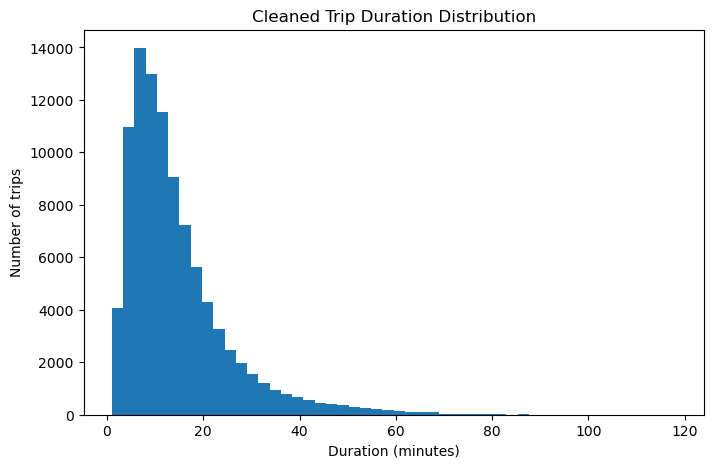

In [21]:
# Visualise cleaned trip duration distribution

plt.figure(figsize=(8, 5))
plt.hist(df_clean["duration_min"], bins=50)
plt.title("Cleaned Trip Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of trips")
plt.show()

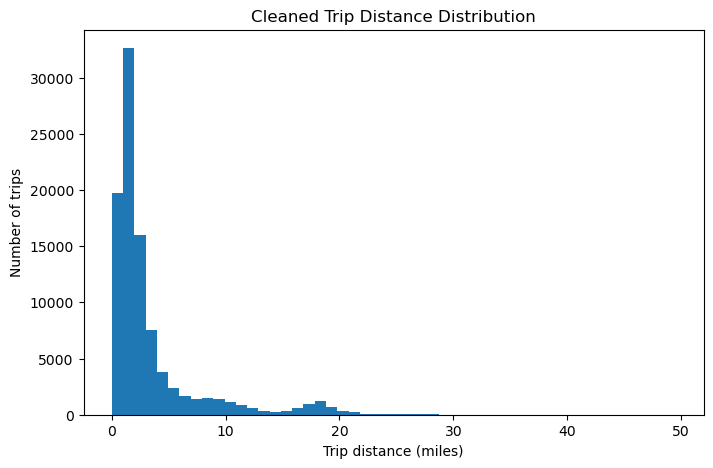

In [25]:
# Visualise cleaned trip distance distribution

plt.figure(figsize=(8, 5))
plt.hist(df_clean["trip_distance"], bins=50)
plt.title("Cleaned Trip Distance Distribution")
plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.show()

### Cleaning interpretation

After cleaning, the dataset retains trips within realistic duration and distance ranges. The distributions remain right-skewed, which is expected for taxi trips because most journeys are short while a smaller number are longer airport or cross-borough trips.

The cleaned dataset will be used for exploratory analysis and modelling.

In [23]:
df = df_clean.copy()

In [24]:
print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print("Rows removed:", rows_removed)
print(f"Percent removed: {percent_removed:.2f}%")
clean_quality_checks

Rows before cleaning: 100000
Rows after cleaning: 95956
Rows removed: 4044
Percent removed: 4.04%


{'negative_or_zero_duration': np.int64(0),
 'duration_less_than_or_equal_1_min': np.int64(0),
 'duration_over_or_equal_2_hours': np.int64(0),
 'zero_or_negative_distance': np.int64(0),
 'distance_over_or_equal_50_miles': np.int64(0)}

In [26]:
# Store cleaned dataset shape

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (95956, 20)


In [27]:
# Check remaining missing values after cleaning

missing_after_cleaning = df_clean.isnull().sum().sort_values(ascending=False)

missing_after_cleaning[missing_after_cleaning > 0]

Series([], dtype: int64)

## 05 Exploratory Data Analysis

This section explores the cleaned taxi trip data before modelling.

The goal is to understand basic travel patterns, including trip duration, trip distance, pickup times, day-of-week patterns, popular pickup zones, and common pickup-dropoff routes.

At this stage, only observed trip characteristics are analysed. The delay target will be created later after splitting the data to avoid leakage.

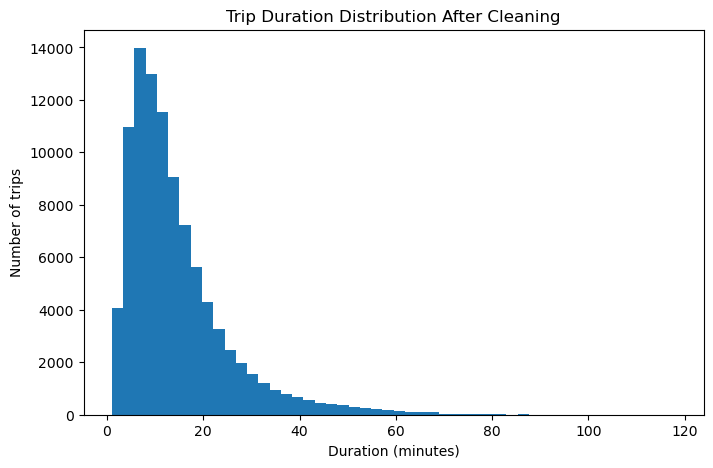

In [28]:
# Trip duration distribution after cleaning

plt.figure(figsize=(8, 5))
plt.hist(df["duration_min"], bins=50)
plt.title("Trip Duration Distribution After Cleaning")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of trips")
plt.show()

Most taxi trips are relatively short, with the distribution strongly right-skewed. This means a large number of trips take only a few minutes, while a smaller number of trips take much longer. This pattern is expected in urban taxi data because many journeys occur within Manhattan or nearby areas, while longer airport or cross-borough trips are less common.

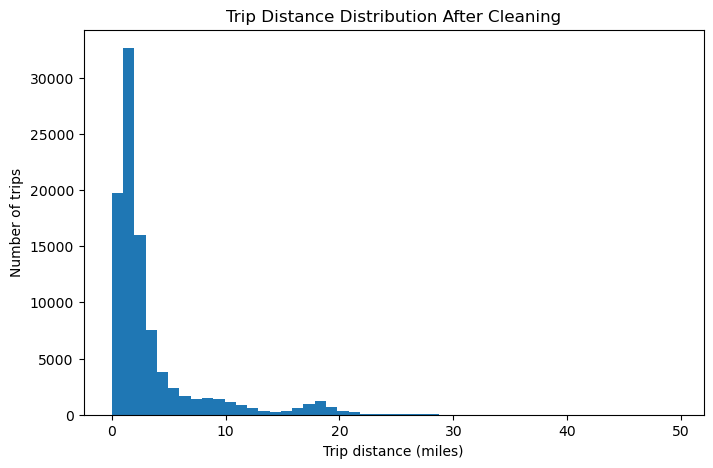

In [29]:
# Trip distance distribution after cleaning

plt.figure(figsize=(8, 5))
plt.hist(df["trip_distance"], bins=50)
plt.title("Trip Distance Distribution After Cleaning")
plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.show()

Trip distance is also right-skewed. Most trips cover short distances, while fewer trips involve longer journeys. This supports the idea that distance will likely be an important feature when estimating expected trip duration and delay risk.

In [30]:
# ============================================
# 05 FEATURE CREATION FOR EDA
# ============================================

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek
df["pickup_day_name"] = df["tpep_pickup_datetime"].dt.day_name()
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

df["is_peak_hour"] = df["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

df[[
    "tpep_pickup_datetime",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day_name",
    "pickup_date",
    "is_weekend",
    "is_peak_hour"
]].head()

,tpep_pickup_datetime,pickup_hour,pickup_dayofweek,pickup_day_name,pickup_date,is_weekend,is_peak_hour
2790731,2023-01-29 17:52:02,17,6,Sunday,2023-01-29,1,1
666153,2023-01-08 15:57:24,15,6,Sunday,2023-01-08,1,0
1985683,2023-01-21 19:38:01,19,5,Saturday,2023-01-21,1,1
2154231,2023-01-23 16:07:31,16,0,Monday,2023-01-23,0,1
2493619,2023-01-26 21:21:08,21,3,Thursday,2023-01-26,0,0


In [31]:
# Trips by pickup hour

trips_by_hour = (
    df.groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

trips_by_hour

,pickup_hour,trip_count
0,0,2620
1,1,1808
2,2,1301
3,3,841
4,4,538
5,5,546
6,6,1326
7,7,2585
8,8,3558
9,9,4091


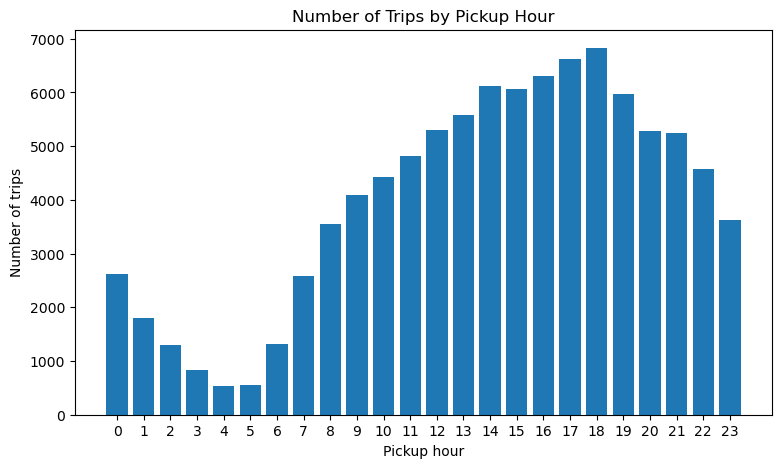

In [32]:
plt.figure(figsize=(9, 5))
plt.bar(trips_by_hour["pickup_hour"], trips_by_hour["trip_count"])
plt.title("Number of Trips by Pickup Hour")
plt.xlabel("Pickup hour")
plt.ylabel("Number of trips")
plt.xticks(range(0, 24))
plt.show()

Trip volume varies by hour of day. This helps show when taxi demand is highest and lowest. Pickup hour may therefore be useful as a modelling feature because taxi demand and traffic conditions are not constant throughout the day.

In [33]:
# Average trip duration by pickup hour

avg_duration_by_hour = (
    df.groupby("pickup_hour")["duration_min"]
    .mean()
    .reset_index(name="avg_duration_min")
)

avg_duration_by_hour

,pickup_hour,avg_duration_min
0,0,13.629
1,1,12.482
2,2,11.684
3,3,12.081
4,4,12.810
5,5,14.835
6,6,14.648
7,7,14.645
8,8,14.154
9,9,13.905


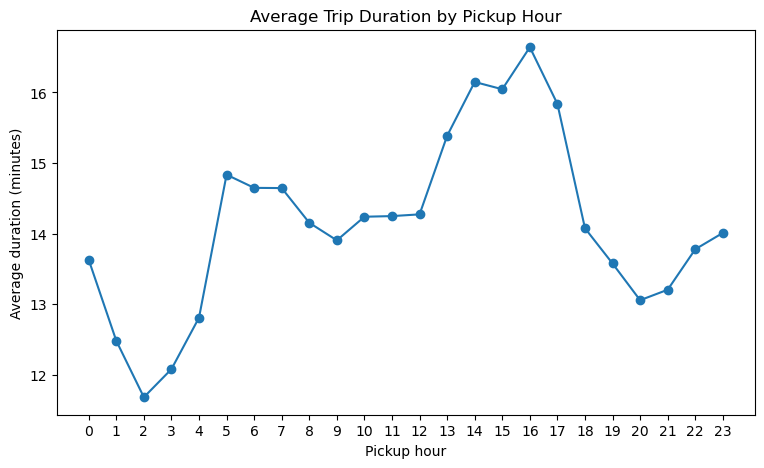

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(avg_duration_by_hour["pickup_hour"], avg_duration_by_hour["avg_duration_min"], marker="o")
plt.title("Average Trip Duration by Pickup Hour")
plt.xlabel("Pickup hour")
plt.ylabel("Average duration (minutes)")
plt.xticks(range(0, 24))
plt.show()

Average trip duration changes across the day, suggesting that time of pickup may influence journey length. Higher average durations during certain hours may reflect congestion, longer trips, airport trips, or changes in passenger demand.

In [35]:
# Trips by day of week

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

trips_by_day = (
    df.groupby("pickup_day_name")
    .size()
    .reindex(day_order)
    .reset_index(name="trip_count")
)

trips_by_day

,pickup_day_name,trip_count
0,Monday,12715
1,Tuesday,15210
2,Wednesday,13152
3,Thursday,13789
4,Friday,13491
5,Saturday,13985
6,Sunday,13614


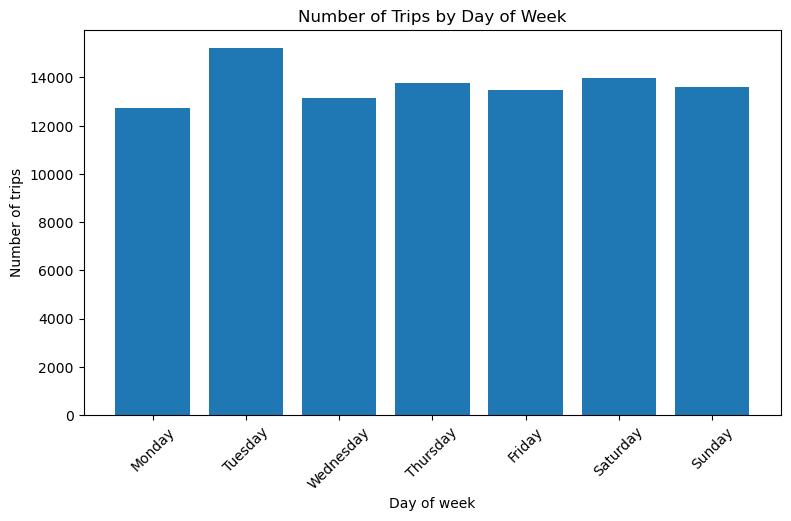

In [36]:
plt.figure(figsize=(9, 5))
plt.bar(trips_by_day["pickup_day_name"], trips_by_day["trip_count"])
plt.title("Number of Trips by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Number of trips")
plt.xticks(rotation=45)
plt.show()

Trip volume differs by day of week. This may reflect weekday commuting patterns, weekend leisure travel, or changes in taxi demand across the week.

In [37]:
# Average trip duration by day of week

avg_duration_by_day = (
    df.groupby("pickup_day_name")["duration_min"]
    .mean()
    .reindex(day_order)
    .reset_index(name="avg_duration_min")
)

avg_duration_by_day

,pickup_day_name,avg_duration_min
0,Monday,14.172
1,Tuesday,14.862
2,Wednesday,14.593
3,Thursday,15.203
4,Friday,15.024
5,Saturday,13.739
6,Sunday,13.854


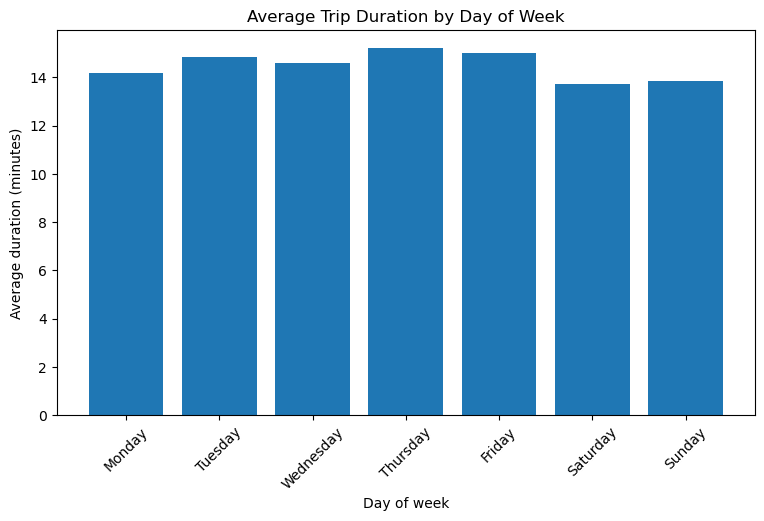

In [38]:
plt.figure(figsize=(9, 5))
plt.bar(avg_duration_by_day["pickup_day_name"], avg_duration_by_day["avg_duration_min"])
plt.title("Average Trip Duration by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Average duration (minutes)")
plt.xticks(rotation=45)
plt.show()

Average duration by day of week gives an early indication of whether trip times vary across weekdays and weekends. This supports including day-of-week and weekend indicators as model features.

In [40]:
# Create pickup-dropoff route identifier

df["route"] = (
    df["PULocationID"].astype(str) 
    + "_" 
    + df["DOLocationID"].astype(str)
)

print("Number of unique routes:", df["route"].nunique())

df[["PULocationID", "DOLocationID", "route"]].head()

Number of unique routes: 6484


,PULocationID,DOLocationID,route
2790731,262,74,262_74
666153,229,237,229_237
1985683,45,261,45_261
2154231,237,141,237_141
2493619,229,140,229_140


In [41]:
# Top pickup location IDs

top_pickup_zones = (
    df.groupby("PULocationID")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="trip_count")
)

top_pickup_zones

,PULocationID,trip_count
0,132,5075
1,237,4677
2,236,4452
3,161,4381
4,186,3440
5,162,3410
6,230,3214
7,142,3180
8,170,2863
9,138,2818


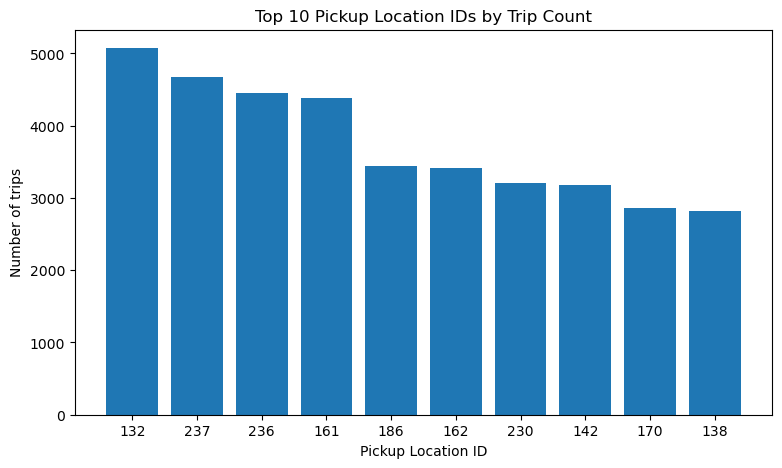

In [42]:
plt.figure(figsize=(9, 5))
plt.bar(top_pickup_zones["PULocationID"].astype(str), top_pickup_zones["trip_count"])
plt.title("Top 10 Pickup Location IDs by Trip Count")
plt.xlabel("Pickup Location ID")
plt.ylabel("Number of trips")
plt.show()

Pickup activity is concentrated in a small number of location IDs. This suggests that geography is important in understanding taxi demand and may also be useful when analysing delay risk later.

In [43]:
# Top pickup-dropoff routes

top_routes = (
    df.groupby("route")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="trip_count")
)

top_routes

,route,trip_count
0,237_236,714
1,236_237,586
2,237_237,465
3,264_264,445
4,236_236,414
5,237_161,302
6,161_237,287
7,141_236,281
8,161_236,266
9,142_239,260


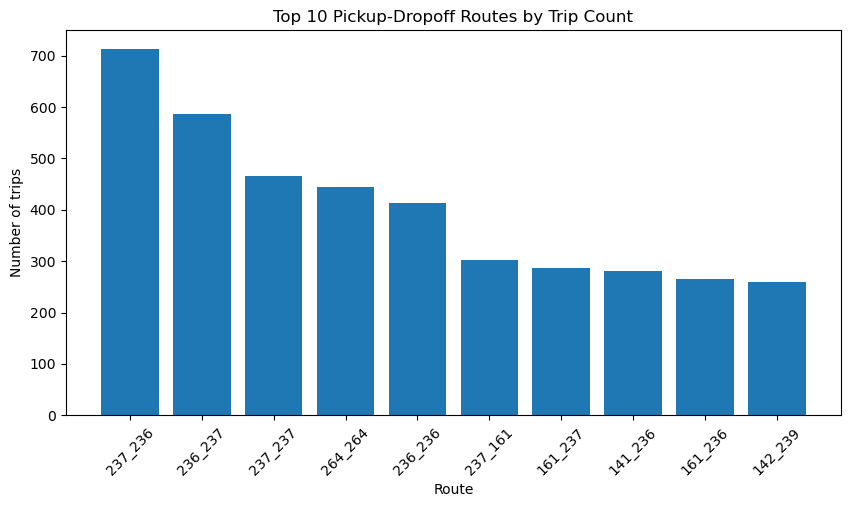

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(top_routes["route"], top_routes["trip_count"])
plt.title("Top 10 Pickup-Dropoff Routes by Trip Count")
plt.xlabel("Route")
plt.ylabel("Number of trips")
plt.xticks(rotation=45)
plt.show()

Some pickup-dropoff route combinations appear much more often than others. Route-level information may capture repeated travel patterns that are not fully explained by distance or pickup time alone.

In [45]:
print("Dataset shape after EDA features:", df.shape)
print("Columns added so far:")
print([
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day_name",
    "pickup_date",
    "pickup_month",
    "is_weekend",
    "is_peak_hour",
    "route"
])

print("Unique routes:", df["route"].nunique())

Dataset shape after EDA features: (95956, 28)
Columns added so far:
['pickup_hour', 'pickup_dayofweek', 'pickup_day_name', 'pickup_date', 'pickup_month', 'is_weekend', 'is_peak_hour', 'route']
Unique routes: 6484


## 06 Leakage-Safe Delay Target Creation

The original version of this project created the delay threshold using the full dataset. This is problematic because information from the test set influences the target definition.

To avoid leakage, the data is first split into training and test sets using a time-based split. The expected trip duration model is then trained only on the training data.

Delay is defined as:

**delay_min = actual duration - expected duration**

A trip is then labelled as high delay risk if its delay is above the 75th percentile of delay values in the training set only.

In [46]:
# ============================================
# 06 SORT DATA BEFORE TIME-BASED SPLIT
# ============================================

df = df.sort_values("tpep_pickup_datetime").copy()

print("Earliest pickup:", df["tpep_pickup_datetime"].min())
print("Latest pickup:", df["tpep_pickup_datetime"].max())
print("Dataset shape:", df.shape)

Earliest pickup: 2022-10-25 09:06:23
Latest pickup: 2023-01-31 23:59:47
Dataset shape: (95956, 28)


In [47]:
# Time-based train/test split

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

print("\nTraining period:")
print(train_df["tpep_pickup_datetime"].min(), "to", train_df["tpep_pickup_datetime"].max())

print("\nTest period:")
print(test_df["tpep_pickup_datetime"].min(), "to", test_df["tpep_pickup_datetime"].max())

Training set shape: (76764, 28)
Test set shape: (19192, 28)

Training period:
2022-10-25 09:06:23 to 2023-01-26 00:14:04

Test period:
2023-01-26 00:14:16 to 2023-01-31 23:59:47


In [48]:
# ============================================
# 07 EXPECTED DURATION MODEL
# ============================================

expected_duration_features = ["trip_distance"]

expected_duration_model = LinearRegression()

expected_duration_model.fit(
    train_df[expected_duration_features],
    train_df["duration_min"]
)

train_df["expected_duration"] = expected_duration_model.predict(
    train_df[expected_duration_features]
)

test_df["expected_duration"] = expected_duration_model.predict(
    test_df[expected_duration_features]
)

In [49]:
# Create delay variable

train_df["delay_min"] = train_df["duration_min"] - train_df["expected_duration"]
test_df["delay_min"] = test_df["duration_min"] - test_df["expected_duration"]

train_df[["duration_min", "trip_distance", "expected_duration", "delay_min"]].describe()

,duration_min,trip_distance,expected_duration,delay_min
count,76764.000,76764.000,76764.000,76764.000
mean,14.470,3.440,14.470,-0.000
std,10.897,4.396,8.974,6.180
min,1.017,0.010,7.468,-46.661
25%,7.183,1.100,9.693,-3.683
50%,11.483,1.800,11.122,-0.975
75%,18.183,3.400,14.389,2.761
max,118.067,49.510,108.531,93.230


In [51]:
test_df[["duration_min", "trip_distance", "expected_duration", "delay_min"]].describe()

,duration_min,trip_distance,expected_duration,delay_min
count,19192.000,19192.000,19192.000,19192.000
mean,14.613,3.273,14.130,0.483
std,10.939,4.141,8.455,6.475
min,1.017,0.030,7.508,-43.235
25%,7.317,1.080,9.652,-3.416
50%,11.667,1.795,11.112,-0.661
75%,18.483,3.250,14.083,3.174
max,114.733,49.500,108.510,75.640


In [52]:
# ============================================
# 08 CLASSIFICATION TARGET
# ============================================

delay_threshold = train_df["delay_min"].quantile(0.75)

train_df["high_delay_risk"] = (
    train_df["delay_min"] > delay_threshold
).astype(int)

test_df["high_delay_risk"] = (
    test_df["delay_min"] > delay_threshold
).astype(int)

print("Delay threshold from training set:", round(delay_threshold, 3))

Delay threshold from training set: 2.761


In [53]:
# Class balance in training set

train_class_balance = train_df["high_delay_risk"].value_counts(normalize=True).rename("proportion")
train_class_counts = train_df["high_delay_risk"].value_counts().rename("count")

pd.concat([train_class_counts, train_class_balance], axis=1)

,count,proportion
high_delay_risk,,
0,57573,0.750
1,19191,0.250


In [55]:
# Class balance in test set

test_class_balance = test_df["high_delay_risk"].value_counts(normalize=True).rename("proportion")
test_class_counts = test_df["high_delay_risk"].value_counts().rename("count")

pd.concat([test_class_counts, test_class_balance], axis=1)

,count,proportion
high_delay_risk,,
0,13986,0.729
1,5206,0.271


### Target creation interpretation

The expected duration model was trained only on the training set using trip distance. This creates a simple estimate of how long a trip should take based on distance.

Delay is calculated as the difference between actual duration and expected duration.

The high-delay-risk threshold is based only on the 75th percentile of training-set delay values. This means the model does not use information from the test set when defining the target.

The training set will have approximately 25% high-delay-risk trips by construction, but the test set may differ because the threshold is fixed from the training data.

In [56]:
print("Delay threshold:", delay_threshold)

print("\nTrain class balance:")
print(train_df["high_delay_risk"].value_counts(normalize=True))

print("\nTest class balance:")
print(test_df["high_delay_risk"].value_counts(normalize=True))

print("\nTrain delay summary:")
print(train_df["delay_min"].describe())

print("\nTest delay summary:")
print(test_df["delay_min"].describe())

Delay threshold: 2.76105148110422

Train class balance:
high_delay_risk
0   0.750
1   0.250
Name: proportion, dtype: float64

Test class balance:
high_delay_risk
0   0.729
1   0.271
Name: proportion, dtype: float64

Train delay summary:
count   76764.000
mean       -0.000
std         6.180
min       -46.661
25%        -3.683
50%        -0.975
75%         2.761
max        93.230
Name: delay_min, dtype: float64

Test delay summary:
count   19192.000
mean        0.483
std         6.475
min       -43.235
25%        -3.416
50%        -0.661
75%         3.174
max        75.640
Name: delay_min, dtype: float64


### Delay target interpretation

The delay threshold is 2.76 minutes, calculated from the 75th percentile of delay values in the training set only.

By definition, 25% of the training trips are labelled as high delay risk. The test set has a slightly different high-delay-risk rate of 27.1%, which confirms that the threshold was not recalculated using the test data.

This avoids the main leakage issue from the original version of the project, where the target threshold was calculated using the full dataset.

## 7 Baseline Regression Model

Before testing machine learning models, a naive baseline is created.

The baseline model predicts the average delay from the training set for every trip in the test set.

This gives a minimum benchmark. A useful model should achieve a lower mean absolute error than this simple baseline.

In [57]:
# ============================================
# 09 REGRESSION MODELLING FEATURES
# ============================================

base_features = [
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "is_weekend",
    "is_peak_hour"
]

X_train_base = train_df[base_features]
X_test_base = test_df[base_features]

y_train_reg = train_df["delay_min"]
y_test_reg = test_df["delay_min"]

print("Training features shape:", X_train_base.shape)
print("Test features shape:", X_test_base.shape)

Training features shape: (76764, 5)
Test features shape: (19192, 5)


In [58]:
# Naive baseline: predict average training delay for every test trip

baseline_delay_prediction = train_df["delay_min"].mean()

baseline_preds = np.repeat(
    baseline_delay_prediction,
    len(test_df)
)

baseline_mae = mean_absolute_error(
    y_test_reg,
    baseline_preds
)

print("Baseline prediction:", round(baseline_delay_prediction, 3))
print("Baseline MAE:", round(baseline_mae, 3))

Baseline prediction: -0.0
Baseline MAE: 4.48


In [59]:
# Linear Regression model

linear_reg = LinearRegression()

linear_reg.fit(X_train_base, y_train_reg)

linear_reg_preds = linear_reg.predict(X_test_base)

linear_reg_mae = mean_absolute_error(
    y_test_reg,
    linear_reg_preds
)

print("Linear Regression MAE:", round(linear_reg_mae, 3))

Linear Regression MAE: 4.461


In [60]:
# Random Forest Regressor

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=12
)

rf_reg.fit(X_train_base, y_train_reg)

rf_reg_preds = rf_reg.predict(X_test_base)

rf_reg_mae = mean_absolute_error(
    y_test_reg,
    rf_reg_preds
)

print("Random Forest Regression MAE:", round(rf_reg_mae, 3))

Random Forest Regression MAE: 3.214


In [61]:
# Regression results comparison

regression_results = pd.DataFrame({
    "Model": [
        "Naive baseline",
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "Features Used": [
        "Training mean delay only",
        ", ".join(base_features),
        ", ".join(base_features)
    ],
    "MAE": [
        baseline_mae,
        linear_reg_mae,
        rf_reg_mae
    ]
})

regression_results["Improvement vs Baseline (%)"] = (
    (baseline_mae - regression_results["MAE"]) / baseline_mae * 100
)

regression_results

,Model,Features Used,MAE,Improvement vs Baseline (%)
0,Naive baseline,Training mean delay only,4.480,0.000
1,Linear Regression,"trip_distance, pickup_hour, pickup_dayofweek, ...",4.461,0.427
2,Random Forest Regressor,"trip_distance, pickup_hour, pickup_dayofweek, ...",3.214,28.254


### Regression model interpretation

The naive baseline predicts the average training delay for every test trip.

The Linear Regression and Random Forest Regressor models are compared against this baseline using mean absolute error.

A lower MAE means the model's delay predictions are closer to the actual delay values on average. The improvement percentage shows whether the machine learning models add useful predictive value beyond simply predicting the average delay.

In [62]:
regression_results

,Model,Features Used,MAE,Improvement vs Baseline (%)
0,Naive baseline,Training mean delay only,4.480,0.000
1,Linear Regression,"trip_distance, pickup_hour, pickup_dayofweek, ...",4.461,0.427
2,Random Forest Regressor,"trip_distance, pickup_hour, pickup_dayofweek, ...",3.214,28.254


### Regression results interpretation

The naive baseline achieved an MAE of 4.48 minutes, meaning that simply predicting the average training delay leads to an average error of around 4.5 minutes on the test set.

Linear Regression only slightly improved on the baseline, reducing MAE by less than 1%. This suggests that the relationship between the current features and delay is not purely linear.

The Random Forest Regressor performed much better, reducing MAE to 3.21 minutes. This is an improvement of approximately 28.3% compared with the naive baseline, showing that non-linear interactions between distance, pickup time, day of week, and peak-hour indicators help explain delay variation.

## 8 Leakage-Safe Route and Demand Features

The first regression models used only basic trip and time features.

This section adds two operational features:

- `route_freq`: how often a pickup-dropoff route appears in the training data
- `hourly_demand`: how many trips occur in each pickup hour in the training data

These features are calculated from the training set only and then applied to the test set. This avoids using future information from the test set.

In [63]:
# ============================================
# 10 CLASSIFICATION MODELLING
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

X_train_class = train_df[base_features]
X_test_class = test_df[base_features]

y_train_class = train_df["high_delay_risk"]
y_test_class = test_df["high_delay_risk"]

classification_results = []

In [64]:
# Majority-class baseline

majority_class = y_train_class.mode()[0]

baseline_class_preds = np.repeat(majority_class, len(y_test_class))
baseline_class_probs = np.repeat(y_train_class.mean(), len(y_test_class))

classification_results.append({
    "Model": "Majority baseline",
    "Accuracy": accuracy_score(y_test_class, baseline_class_preds),
    "Precision": precision_score(y_test_class, baseline_class_preds, zero_division=0),
    "Recall": recall_score(y_test_class, baseline_class_preds, zero_division=0),
    "F1": f1_score(y_test_class, baseline_class_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_class, baseline_class_probs)
})

In [65]:
# Logistic Regression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_class, y_train_class)

log_reg_preds = log_reg.predict(X_test_class)
log_reg_probs = log_reg.predict_proba(X_test_class)[:, 1]

classification_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test_class, log_reg_preds),
    "Precision": precision_score(y_test_class, log_reg_preds, zero_division=0),
    "Recall": recall_score(y_test_class, log_reg_preds, zero_division=0),
    "F1": f1_score(y_test_class, log_reg_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_class, log_reg_probs)
})

In [66]:
# Random Forest Classifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_clf.fit(X_train_class, y_train_class)

rf_clf_preds = rf_clf.predict(X_test_class)
rf_clf_probs = rf_clf.predict_proba(X_test_class)[:, 1]

classification_results.append({
    "Model": "Random Forest Classifier",
    "Accuracy": accuracy_score(y_test_class, rf_clf_preds),
    "Precision": precision_score(y_test_class, rf_clf_preds, zero_division=0),
    "Recall": recall_score(y_test_class, rf_clf_preds, zero_division=0),
    "F1": f1_score(y_test_class, rf_clf_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_class, rf_clf_probs)
})

In [67]:
classification_results = pd.DataFrame(classification_results)
classification_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority baseline,0.729,0.000,0.000,0.000,0.500
1,Logistic Regression,0.728,0.484,0.032,0.060,0.620
2,Random Forest Classifier,0.775,0.564,0.750,0.644,0.849


## 9 Best Classifier Evaluation

The Random Forest Classifier performed best overall, with the highest F1-score and ROC-AUC.

Accuracy alone is not enough because high-delay-risk trips are the minority class. Therefore, the model is also evaluated using precision, recall, F1-score, ROC-AUC, and a confusion matrix.

In [68]:
# Detailed classification report for Random Forest Classifier

print(classification_report(y_test_class, rf_clf_preds))

              precision    recall  f1-score   support

           0       0.89      0.78      0.84     13986
           1       0.56      0.75      0.64      5206

    accuracy                           0.77     19192
   macro avg       0.73      0.77      0.74     19192
weighted avg       0.80      0.77      0.78     19192



In [69]:
# Confusion matrix for Random Forest Classifier

cm = confusion_matrix(y_test_class, rf_clf_preds)

cm_df = pd.DataFrame(
    cm,
    index=["Actual normal", "Actual high delay risk"],
    columns=["Predicted normal", "Predicted high delay risk"]
)

cm_df

,Predicted normal,Predicted high delay risk
Actual normal,10965,3021
Actual high delay risk,1302,3904


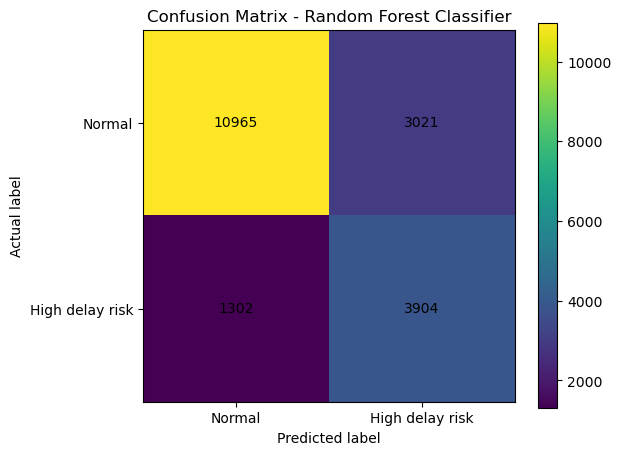

In [70]:
# Confusion matrix visualisation

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.xticks([0, 1], ["Normal", "High delay risk"])
plt.yticks([0, 1], ["Normal", "High delay risk"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

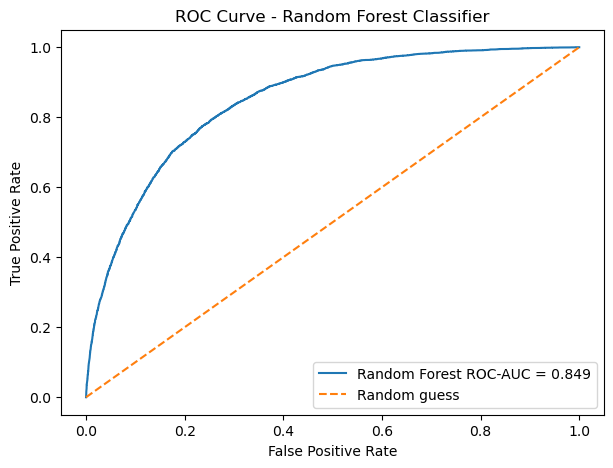

In [71]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_class, rf_clf_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest ROC-AUC = {roc_auc_score(y_test_class, rf_clf_probs):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.title("ROC Curve - Random Forest Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

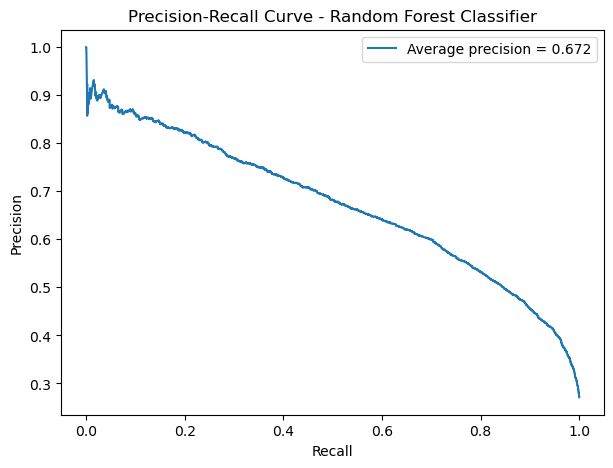

In [72]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test_class, rf_clf_probs)
avg_precision = average_precision_score(y_test_class, rf_clf_probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Average precision = {avg_precision:.3f}")
plt.title("Precision-Recall Curve - Random Forest Classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

### Classification results interpretation

The majority baseline achieves 72.9% accuracy because most trips are not high delay risk. However, it completely fails to identify high-delay-risk trips, with precision, recall, and F1-score all equal to zero.

Logistic Regression performs only slightly better than the baseline. Its recall is very low, meaning it misses most high-delay-risk trips.

The Random Forest Classifier performs best. It achieves 77.5% accuracy, an F1-score of 0.644, and a ROC-AUC of 0.849. The recall score of 0.750 means the model identifies around 75% of high-delay-risk trips.

This makes Random Forest the strongest classification model in this version of the project. However, precision is 0.564, meaning some trips predicted as high delay risk are false positives. In a business setting, this may still be acceptable if the goal is to flag risky trips early rather than guarantee every flagged trip will be delayed.

In [73]:
cm_df
print(classification_report(y_test_class, rf_clf_preds))

              precision    recall  f1-score   support

           0       0.89      0.78      0.84     13986
           1       0.56      0.75      0.64      5206

    accuracy                           0.77     19192
   macro avg       0.73      0.77      0.74     19192
weighted avg       0.80      0.77      0.78     19192



## 10 Feature Importance

Feature importance helps explain which variables were most useful to the Random Forest Classifier.

This does not prove causation, but it gives useful insight into which trip characteristics are most associated with high delay risk.

In [74]:
# ============================================
# 11 FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "Feature": base_features,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
0,trip_distance,0.718
1,pickup_hour,0.195
2,pickup_dayofweek,0.065
3,is_weekend,0.013
4,is_peak_hour,0.009


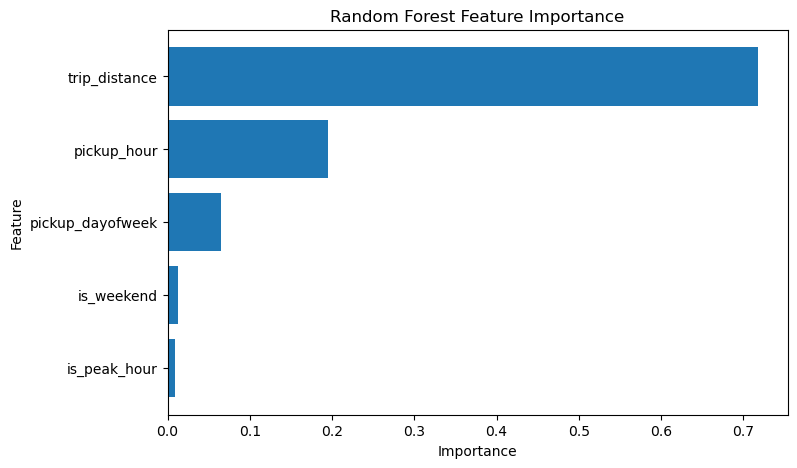

In [75]:
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

## 11 Geospatial Analysis

This section explores how taxi activity and delay vary by pickup zone.

Two maps are created:

1. Trip volume by pickup zone
2. Average delay by pickup zone

This helps identify whether delay risk is concentrated in specific areas of NYC.

In [78]:
# ============================================
# 12 GEOSPATIAL ANALYSIS
# ============================================

import geopandas as gpd
import zipfile
import os

# Extract shapefile only if the folder does not already exist
if not os.path.exists("taxi_zones_extracted"):
    with zipfile.ZipFile("taxi_zones.zip", "r") as zip_ref:
        zip_ref.extractall("taxi_zones_extracted")

zones = gpd.read_file(r"taxi_zones_extracted\taxi_zones\taxi_zones.shp")

print(zones.shape)
zones.head()

(263, 7)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116,0.001,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433,0.005,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084,0.000,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.044,0.000,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092,0.000,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [79]:
zones[["LocationID", "zone", "borough", "geometry"]].head()

,LocationID,zone,borough,geometry
0,1,Newark Airport,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,Jamaica Bay,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,Allerton/Pelham Gardens,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,Alphabet City,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,Arden Heights,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [80]:
# Trip volume by pickup zone

pickup_volume = (
    df.groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
)

pickup_volume_map = zones.merge(
    pickup_volume,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

pickup_volume_map["trip_count"] = pickup_volume_map["trip_count"].fillna(0)
pickup_volume_map["log_trip_count"] = np.log1p(pickup_volume_map["trip_count"])

pickup_volume_map[["LocationID", "zone", "borough", "trip_count"]].head()

,LocationID,zone,borough,trip_count
0,1,Newark Airport,EWR,0.000
1,2,Jamaica Bay,Queens,0.000
2,3,Allerton/Pelham Gardens,Bronx,3.000
3,4,Alphabet City,Manhattan,105.000
4,5,Arden Heights,Staten Island,3.000


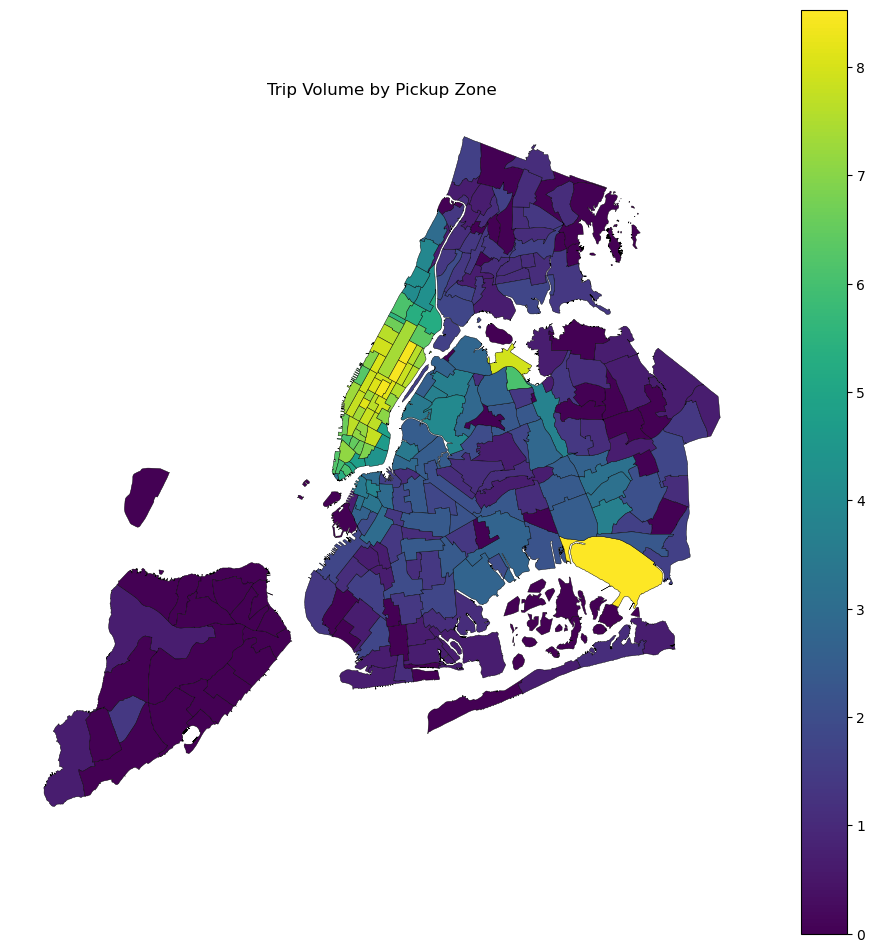

In [81]:
# Plot trip volume map

fig, ax = plt.subplots(figsize=(12, 12))

pickup_volume_map.plot(
    column="log_trip_count",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Trip Volume by Pickup Zone")
ax.axis("off")

plt.show()

Trip volume is not evenly distributed across NYC. Pickup activity is concentrated in central business and transport-heavy areas, especially zones associated with Manhattan and major travel hubs.

A log scale is used because some zones have much higher pickup volume than others.

In [82]:
# Combine train and test data for post-model geospatial analysis

df_modelled = pd.concat([train_df, test_df], axis=0).copy()

print(df_modelled.shape)
print(df_modelled["delay_min"].isnull().sum())

(95956, 31)
0


In [83]:
# Average delay by pickup zone

pickup_delay = (
    df_modelled.groupby("PULocationID")["delay_min"]
    .mean()
    .reset_index(name="avg_delay_min")
)

pickup_delay_map = zones.merge(
    pickup_delay,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

pickup_delay_map[["LocationID", "zone", "borough", "avg_delay_min"]].head()

,LocationID,zone,borough,avg_delay_min
0,1,Newark Airport,EWR,NaN
1,2,Jamaica Bay,Queens,NaN
2,3,Allerton/Pelham Gardens,Bronx,3.933
3,4,Alphabet City,Manhattan,-0.692
4,5,Arden Heights,Staten Island,7.848


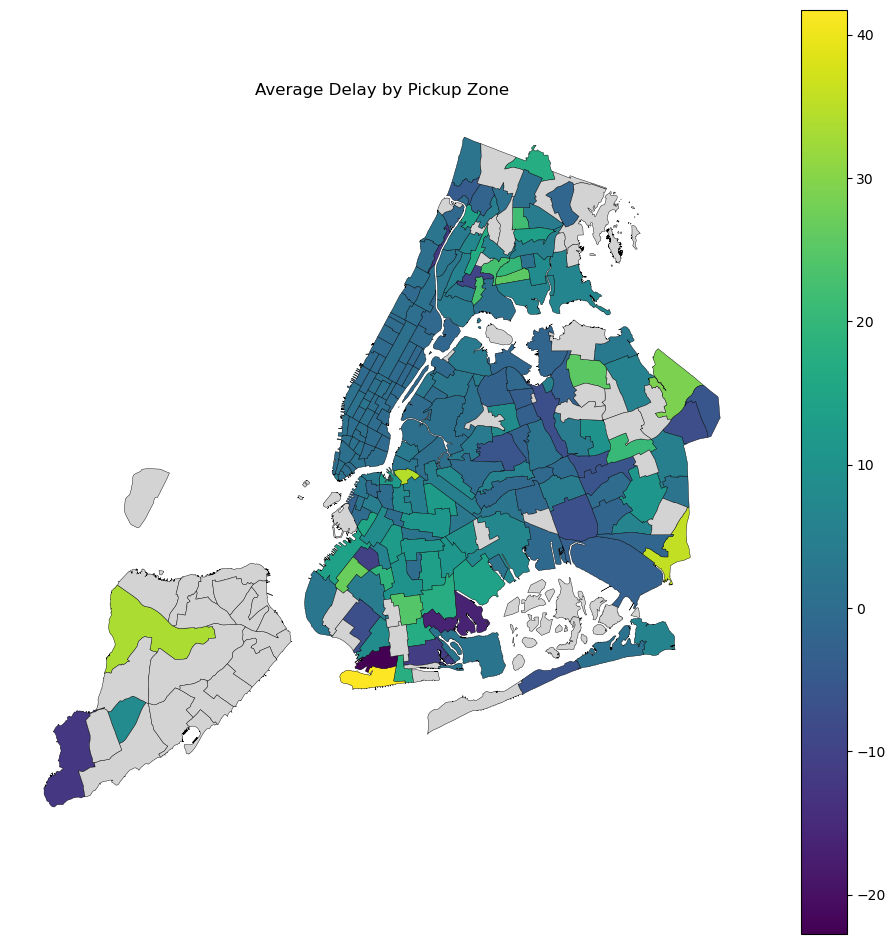

In [84]:
# Plot average delay map

fig, ax = plt.subplots(figsize=(12, 12))

pickup_delay_map.plot(
    column="avg_delay_min",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No trips"
    },
    ax=ax
)

ax.set_title("Average Delay by Pickup Zone")
ax.axis("off")

plt.show()

Average delay varies by pickup zone, suggesting that geography contains useful operational information.

Some zones may have relatively high delay even if they are not the busiest pickup areas. This shows why volume and delay should be analysed separately.

In [85]:
# Top pickup zones by average delay
# Only include zones with at least 30 trips to avoid unstable averages

pickup_zone_summary = (
    df_modelled.groupby("PULocationID")
    .agg(
        trip_count=("PULocationID", "size"),
        avg_delay_min=("delay_min", "mean"),
        high_delay_risk_rate=("high_delay_risk", "mean")
    )
    .reset_index()
)

pickup_zone_summary = pickup_zone_summary.merge(
    zones[["LocationID", "zone", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

top_delay_zones = (
    pickup_zone_summary[pickup_zone_summary["trip_count"] >= 30]
    .sort_values("avg_delay_min", ascending=False)
    .head(10)
)

top_delay_zones[[
    "PULocationID",
    "zone",
    "borough",
    "trip_count",
    "avg_delay_min",
    "high_delay_risk_rate"
]]

,PULocationID,zone,borough,trip_count,avg_delay_min,high_delay_risk_rate
199,255,Williamsburg (North Side),Brooklyn,30,3.221,0.467
3,7,Astoria,Queens,38,2.706,0.316
22,33,Brooklyn Heights,Brooklyn,31,2.642,0.387
142,186,Penn Station/Madison Sq West,Manhattan,3440,2.266,0.390
205,261,World Trade Center,Manhattan,412,1.786,0.410
52,68,East Chelsea,Manhattan,2360,1.665,0.342
86,116,Hamilton Heights,Manhattan,65,1.649,0.246
34,45,Chinatown,Manhattan,116,1.589,0.345
31,42,Central Harlem North,Manhattan,68,1.325,0.265
121,158,Meatpacking/West Village West,Manhattan,748,1.304,0.316


To avoid overinterpreting zones with very few trips, the top delayed pickup zones table only includes zones with at least 30 sampled trips.

This gives a more reliable view of which areas are associated with higher average delay.

In [86]:
top_delay_zones[[
    "PULocationID",
    "zone",
    "borough",
    "trip_count",
    "avg_delay_min",
    "high_delay_risk_rate"
]]

,PULocationID,zone,borough,trip_count,avg_delay_min,high_delay_risk_rate
199,255,Williamsburg (North Side),Brooklyn,30,3.221,0.467
3,7,Astoria,Queens,38,2.706,0.316
22,33,Brooklyn Heights,Brooklyn,31,2.642,0.387
142,186,Penn Station/Madison Sq West,Manhattan,3440,2.266,0.390
205,261,World Trade Center,Manhattan,412,1.786,0.410
52,68,East Chelsea,Manhattan,2360,1.665,0.342
86,116,Hamilton Heights,Manhattan,65,1.649,0.246
34,45,Chinatown,Manhattan,116,1.589,0.345
31,42,Central Harlem North,Manhattan,68,1.325,0.265
121,158,Meatpacking/West Village West,Manhattan,748,1.304,0.316


### Geospatial interpretation

The pickup-zone analysis shows that average delay is not only concentrated in the busiest areas.

Williamsburg (North Side), Astoria, and Brooklyn Heights have some of the highest average delays among zones with at least 30 sampled trips, although their trip volumes are relatively small. This suggests that some lower-volume zones may still carry higher delay risk.

Penn Station/Madison Square West is especially important because it combines high volume with high delay risk. It has 3,440 trips, an average delay of 2.27 minutes, and a high-delay-risk rate of 39.0%. This makes it a more operationally important delay hotspot than zones with fewer trips.

World Trade Center also shows a high-delay-risk rate of 41.0%, suggesting that central business and transport-heavy zones may be associated with elevated delay risk.

## 12 Business Insights

This project looked at whether we can predict taxi trips that are likely to take longer than expected.

The answer is yes. The model can identify many high-delay-risk trips using simple trip information such as distance, pickup time, day of week, and whether the trip starts during peak hours.

The best regression model was the Random Forest model. It reduced the average prediction error from 4.48 minutes to 3.21 minutes compared with a simple baseline. This means the model gives a noticeably better estimate than simply guessing the average delay.

The best classification model was also Random Forest. It correctly identified around 75% of high-delay-risk trips. This is useful because the model can act as an early warning system for trips that may take longer than expected.

The model is not perfect. Some trips flagged as high risk will not actually be delayed. However, for business use, this may still be helpful because it is better to warn about possible delay than to miss many delayed trips.

The map analysis showed that delay is not only a problem in the busiest areas. Some lower-volume areas, such as Williamsburg (North Side), Astoria, and Brooklyn Heights, had high average delays. Penn Station/Madison Square West is especially important because it had both high trip volume and high delay risk.

## 13 Recommendations

Based on the analysis, taxi operators or transport analysts could use this type of model to:

1. Flag trips that are more likely to take longer than expected.

2. Give passengers more realistic journey-time expectations.

3. Monitor delay hotspots such as Penn Station/Madison Square West.

4. Compare busy zones with high-delay zones, because the busiest places are not always the most delayed.

5. Use pickup time and trip distance as key early indicators of delay risk.

## 14 Limitations

This project has some limitations.

Only January 2023 data was used, so the results may be different in other months.

The model does not include weather, road closures, events, or live traffic data. These factors could have a big effect on taxi delays.

The definition of high delay risk is based on this dataset. It means trips that are much slower than expected compared with other trips in the training data.

The model was built using a 100,000-row sample rather than the full dataset to keep the notebook easier to run.

The results show patterns and useful signals, but they do not prove that one factor directly causes delay.

## 15 Future Improvements

The project could be improved by:

1. Using several months of taxi data instead of only January 2023.

2. Adding weather, holiday, and major event data.

3. Adding more location-based features, such as pickup and dropoff borough.

4. Testing more advanced models such as XGBoost or LightGBM.

5. Building a Tableau dashboard so the results can be explored visually.

6. Recreating the main summaries in SQL to show how the analysis could be done in a business database.